<a href="https://colab.research.google.com/github/Usman-938/AI-ML-Internship-Tasks-/blob/main/Stock_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2: Predict Future Stock Prices (Short-Term)
**Objective:** Use historical stock data to predict the next day's closing price.

**Dataset:** Yahoo Finance via yfinance library (Apple and Tesla stocks)

**Models Used:** Linear Regression and Random Forest Regressor

**Author:** Muhammad Usman
**GitHub:** Usman-938
**LinkedIn:** m-usman-i938

---

### Problem Statement
Stock markets generate billions of data points daily. Short-term price prediction — forecasting tomorrow's closing price based on today's trading activity — is one of the most challenging and valuable problems in quantitative finance.

### Goal
- Use features: Open, High, Low, Volume plus technical indicators to predict next day's Close price
- Train Linear Regression and Random Forest models
- Evaluate using MAE, RMSE, and R2
- Plot Actual vs Predicted closing prices over time

## Step 1: Install and Import Libraries

In [1]:
# Install yfinance (not pre-installed in Colab)
!pip install -q yfinance scikit-learn pandas numpy matplotlib seaborn

In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Fetching
import yfinance as yf
from datetime import datetime

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Plot Style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')

print('All libraries imported successfully!')
print('yfinance version:', yf.__version__)

All libraries imported successfully!
yfinance version: 0.2.66


## Step 2: Load Stock Data via yfinance

We fetch 5 years of daily OHLCV data for Apple (AAPL) and Tesla (TSLA) directly from Yahoo Finance. Primary focus is Apple for modeling; Tesla is used for comparison.

In [3]:
# Configuration
TICKER     = 'AAPL'
TICKER2    = 'TSLA'
START_DATE = '2019-01-01'
END_DATE   = datetime.today().strftime('%Y-%m-%d')

print('Fetching', TICKER, 'data from', START_DATE, 'to', END_DATE)

# Download data
raw_aapl = yf.download(TICKER,  start=START_DATE, end=END_DATE, progress=False)
raw_tsla = yf.download(TICKER2, start=START_DATE, end=END_DATE, progress=False)

# Flatten multi-level columns if present (newer yfinance versions)
if isinstance(raw_aapl.columns, pd.MultiIndex):
    raw_aapl.columns = raw_aapl.columns.get_level_values(0)
if isinstance(raw_tsla.columns, pd.MultiIndex):
    raw_tsla.columns = raw_tsla.columns.get_level_values(0)

df = raw_aapl.copy()

print('\nAAPL loaded:', len(df), 'trading days')
print('Date range:', df.index[0].date(), 'to', df.index[-1].date())
print('Columns:', list(df.columns))
print('\nTSLA loaded:', len(raw_tsla), 'trading days')
df.head(10)

Fetching AAPL data from 2019-01-01 to 2026-04-02

AAPL loaded: 1822 trading days
Date range: 2019-01-02 to 2026-04-01
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

TSLA loaded: 1822 trading days


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.503723,37.724587,36.627401,36.784142,148158800
2019-01-03,33.768070,34.606394,33.722947,34.193168,365248800
2019-01-04,35.209614,35.278487,34.150430,34.323794,234428400
2019-01-07,35.131245,35.344984,34.649149,35.314110,219111200
2019-01-08,35.800957,36.055068,35.271365,35.518348,164101200
2019-01-09,36.408924,36.698657,35.534979,35.929202,180396400
2019-01-10,36.525295,36.565667,35.827087,36.216563,143122800
2019-01-11,36.166676,36.501531,35.981437,36.306795,108092800
2019-01-14,35.622833,35.924441,35.437595,35.824697,129756800


## Step 3: Data Cleaning and Feature Engineering

Raw OHLCV data alone is not sufficient for prediction. We engineer technical indicators widely used in financial analysis to improve model performance.

In [4]:
# 3.1 Basic Overview
print('DATASET OVERVIEW')
print('Shape       :', df.shape)
print('Missing vals:', df.isnull().sum().sum())
print('Duplicates  :', df.index.duplicated().sum())
print()
df.describe().round(2)

DATASET OVERVIEW
Shape       : (1822, 5)
Missing vals: 0
Duplicates  : 0



Price,Close,High,Low,Open,Volume
count,1822.00,1822.00,1822.00,1822.00,1.822000e+03
mean,152.14,153.69,150.45,152.01,8.710550e+07
std,63.48,64.04,62.91,63.46,5.093487e+07
min,33.77,34.61,33.72,34.19,1.791060e+07
25%,114.09,115.98,112.96,114.61,5.187240e+07
50%,153.06,154.59,150.78,152.43,7.450635e+07
75%,193.63,195.42,192.29,193.47,1.053540e+08
max,285.92,288.35,283.04,285.93,4.265100e+08


In [5]:
# 3.2 Handle Missing Values
missing = df.isnull().sum()
if missing.sum() > 0:
    print('Missing values found:', missing[missing > 0].to_dict())
else:
    print('No missing values - dataset is clean!')

df.dropna(inplace=True)
print('Rows after cleaning:', len(df))

No missing values - dataset is clean!
Rows after cleaning: 1822


In [6]:
# 3.3 Feature Engineering - Technical Indicators
# Price-based features
df['Price_Range']    = df['High'] - df['Low']
df['Price_Change']   = df['Close'] - df['Open']
df['Pct_Change']     = df['Close'].pct_change() * 100

# Moving Averages
df['MA_5']           = df['Close'].rolling(window=5).mean()
df['MA_20']          = df['Close'].rolling(window=20).mean()
df['MA_50']          = df['Close'].rolling(window=50).mean()

# Exponential Moving Averages
df['EMA_12']         = df['Close'].ewm(span=12, adjust=False).mean()
df['EMA_26']         = df['Close'].ewm(span=26, adjust=False).mean()

# MACD - Momentum indicator
df['MACD']           = df['EMA_12'] - df['EMA_26']

# Bollinger Bands - Volatility
bb_std               = df['Close'].rolling(window=20).std()
df['BB_Upper']       = df['MA_20'] + (2 * bb_std)
df['BB_Lower']       = df['MA_20'] - (2 * bb_std)
df['BB_Width']       = df['BB_Upper'] - df['BB_Lower']

# RSI - Relative Strength Index
delta = df['Close'].diff()
gain  = delta.where(delta > 0, 0).rolling(window=14).mean()
loss  = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs    = gain / (loss + 1e-10)
df['RSI']            = 100 - (100 / (1 + rs))

# Volume features
df['Volume_MA']      = df['Volume'].rolling(window=5).mean()
df['Volume_Ratio']   = df['Volume'] / (df['Volume_MA'] + 1)

# Lag features - previous days close prices
df['Close_Lag1']     = df['Close'].shift(1)
df['Close_Lag2']     = df['Close'].shift(2)
df['Close_Lag3']     = df['Close'].shift(3)

# TARGET: Next day Close price
df['Target']         = df['Close'].shift(-1)

# Drop NaN rows from rolling/lag operations
df.dropna(inplace=True)

print('Feature engineering complete!')
print('Total usable rows:', len(df))
print('Total columns    :', df.shape[1])

Feature engineering complete!
Total usable rows: 1772
Total columns    : 24


## Step 4: Exploratory Data Analysis (EDA)

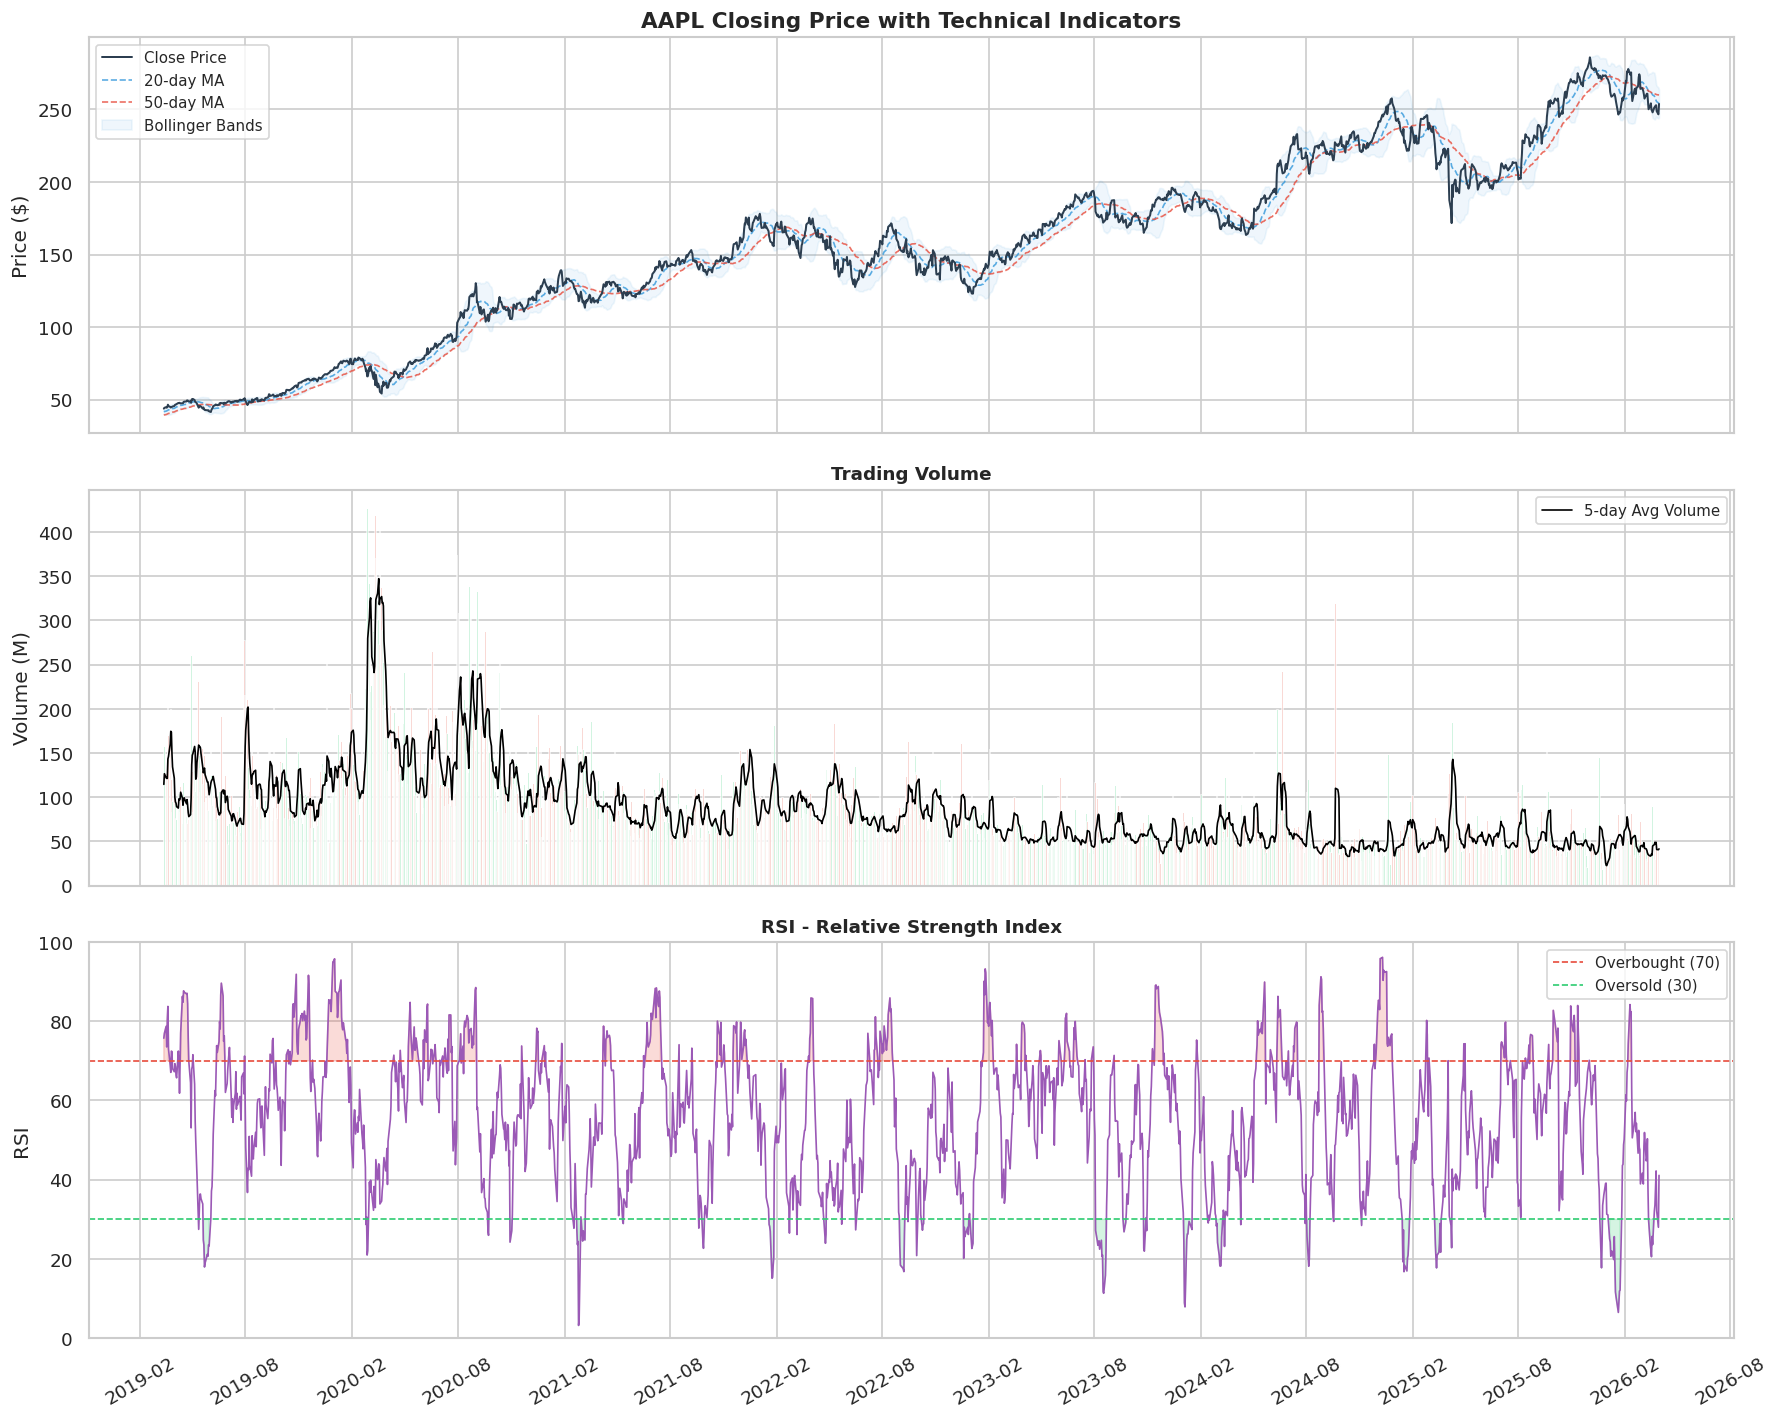

In [7]:
# 4.1 Historical Price Chart with Moving Averages and RSI
fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)

# Price + Moving Averages + Bollinger Bands
axes[0].plot(df.index, df['Close'], color='#2c3e50', linewidth=1.2, label='Close Price', zorder=3)
axes[0].plot(df.index, df['MA_20'], color='#3498db', linewidth=1, linestyle='--', alpha=0.8, label='20-day MA')
axes[0].plot(df.index, df['MA_50'], color='#e74c3c', linewidth=1, linestyle='--', alpha=0.8, label='50-day MA')
axes[0].fill_between(df.index, df['BB_Upper'], df['BB_Lower'], alpha=0.08, color='#3498db', label='Bollinger Bands')
axes[0].set_title(TICKER + ' Closing Price with Technical Indicators', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend(loc='upper left', fontsize=9)

# Volume bars colored by price direction
colors_vol = ['#2ecc71' if c >= o else '#e74c3c' for c, o in zip(df['Close'], df['Open'])]
axes[1].bar(df.index, df['Volume'] / 1e6, color=colors_vol, alpha=0.7, width=1)
axes[1].plot(df.index, df['Volume_MA'] / 1e6, color='black', linewidth=1, label='5-day Avg Volume')
axes[1].set_ylabel('Volume (M)')
axes[1].set_title('Trading Volume', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# RSI
axes[2].plot(df.index, df['RSI'], color='#9b59b6', linewidth=1)
axes[2].axhline(70, color='#e74c3c', linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='#2ecc71', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].fill_between(df.index, df['RSI'], 70, where=(df['RSI'] >= 70), alpha=0.2, color='#e74c3c')
axes[2].fill_between(df.index, df['RSI'], 30, where=(df['RSI'] <= 30), alpha=0.2, color='#2ecc71')
axes[2].set_ylabel('RSI')
axes[2].set_title('RSI - Relative Strength Index', fontsize=11, fontweight='bold')
axes[2].set_ylim([0, 100])
axes[2].legend(fontsize=9)

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('stock_overview.png', bbox_inches='tight')
plt.show()

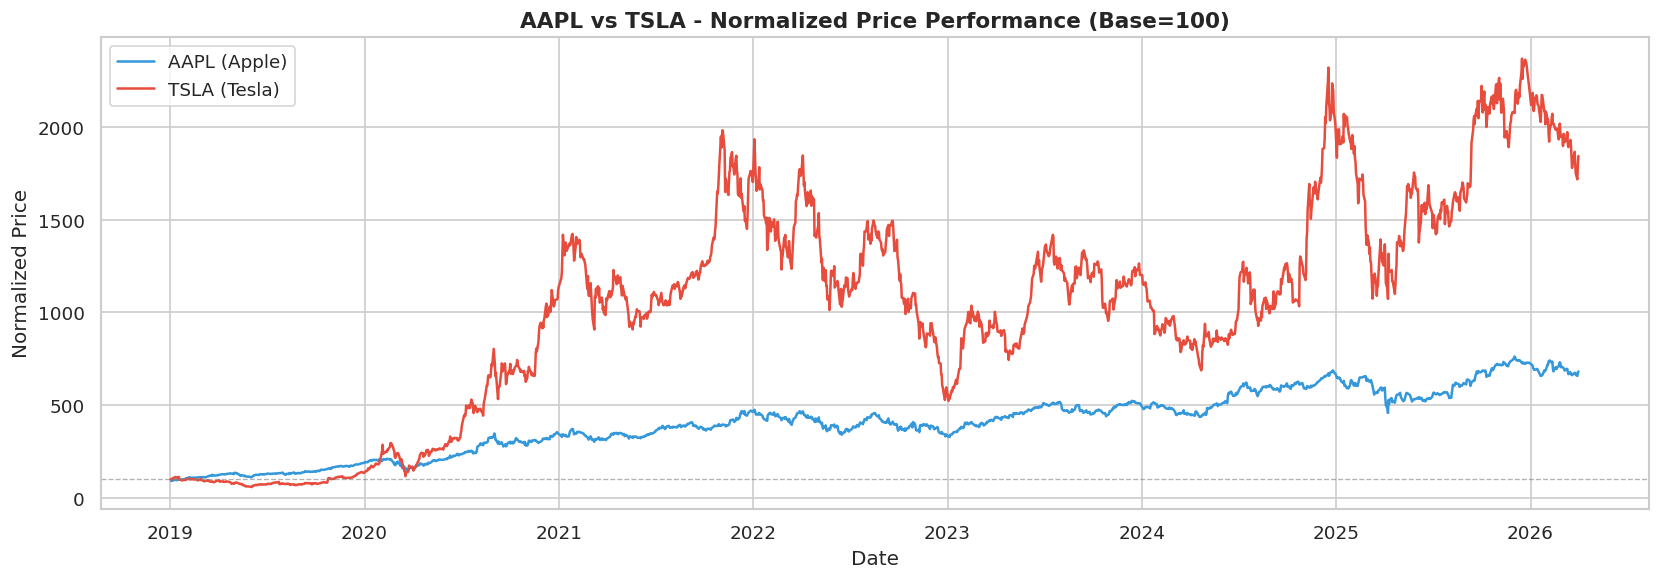

AAPL total return since 2019-01-01 : 581.6 %
TSLA total return since 2019-01-01 : 1744.1 %


In [8]:
# 4.2 AAPL vs TSLA Normalized Price Comparison
plt.figure(figsize=(14, 5))

aapl_norm = (raw_aapl['Close'] / raw_aapl['Close'].iloc[0]) * 100
tsla_norm = (raw_tsla['Close'] / raw_tsla['Close'].iloc[0]) * 100

plt.plot(aapl_norm.index, aapl_norm, color='#3498db', linewidth=1.5, label='AAPL (Apple)')
plt.plot(tsla_norm.index, tsla_norm, color='#e74c3c', linewidth=1.5, label='TSLA (Tesla)')
plt.axhline(100, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

plt.title('AAPL vs TSLA - Normalized Price Performance (Base=100)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Normalized Price')
plt.legend(fontsize=11)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig('aapl_vs_tsla.png', bbox_inches='tight')
plt.show()

aapl_ret = ((raw_aapl['Close'].iloc[-1] / raw_aapl['Close'].iloc[0]) - 1) * 100
tsla_ret = ((raw_tsla['Close'].iloc[-1] / raw_tsla['Close'].iloc[0]) - 1) * 100
print('AAPL total return since', START_DATE, ':', round(aapl_ret, 1), '%')
print('TSLA total return since', START_DATE, ':', round(tsla_ret, 1), '%')

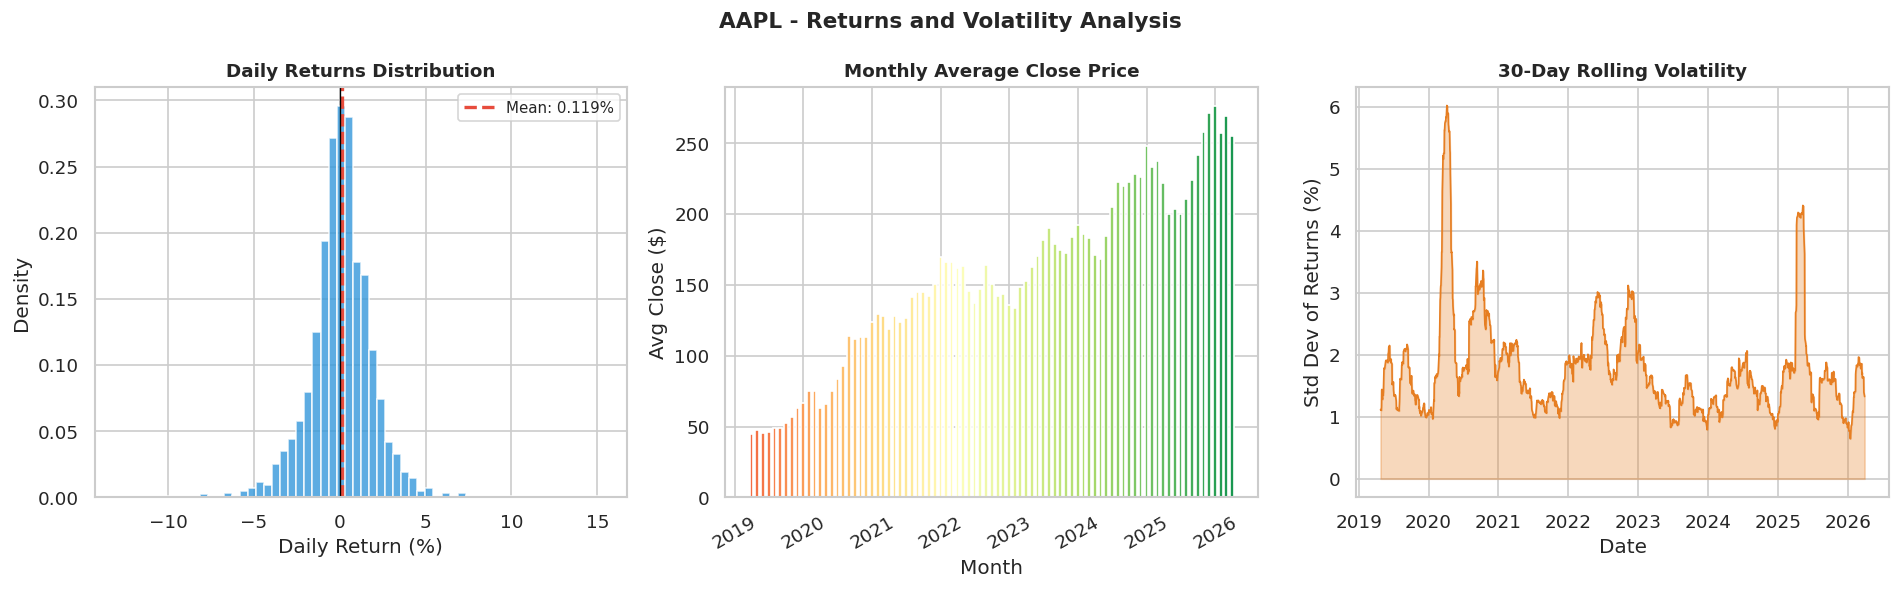

In [9]:
# 4.3 Returns Distribution and Rolling Volatility
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Daily returns histogram
returns = df['Pct_Change'].dropna()
axes[0].hist(returns, bins=60, color='#3498db', edgecolor='white', alpha=0.8, density=True)
axes[0].axvline(returns.mean(), color='#e74c3c', linestyle='--', linewidth=2,
                label='Mean: ' + str(round(returns.mean(), 3)) + '%')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Daily Returns Distribution', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Daily Return (%)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Monthly average close
monthly = df['Close'].resample('ME').mean()
axes[1].bar(monthly.index, monthly.values, width=20,
            color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(monthly))),
            edgecolor='white')
axes[1].set_title('Monthly Average Close Price', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Close ($)')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)

# 30-day Rolling Volatility
rolling_vol = df['Pct_Change'].rolling(30).std()
axes[2].plot(df.index, rolling_vol, color='#e67e22', linewidth=1)
axes[2].fill_between(df.index, rolling_vol, alpha=0.3, color='#e67e22')
axes[2].set_title('30-Day Rolling Volatility', fontsize=11, fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Std Dev of Returns (%)')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle(TICKER + ' - Returns and Volatility Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('returns_analysis.png', bbox_inches='tight')
plt.show()

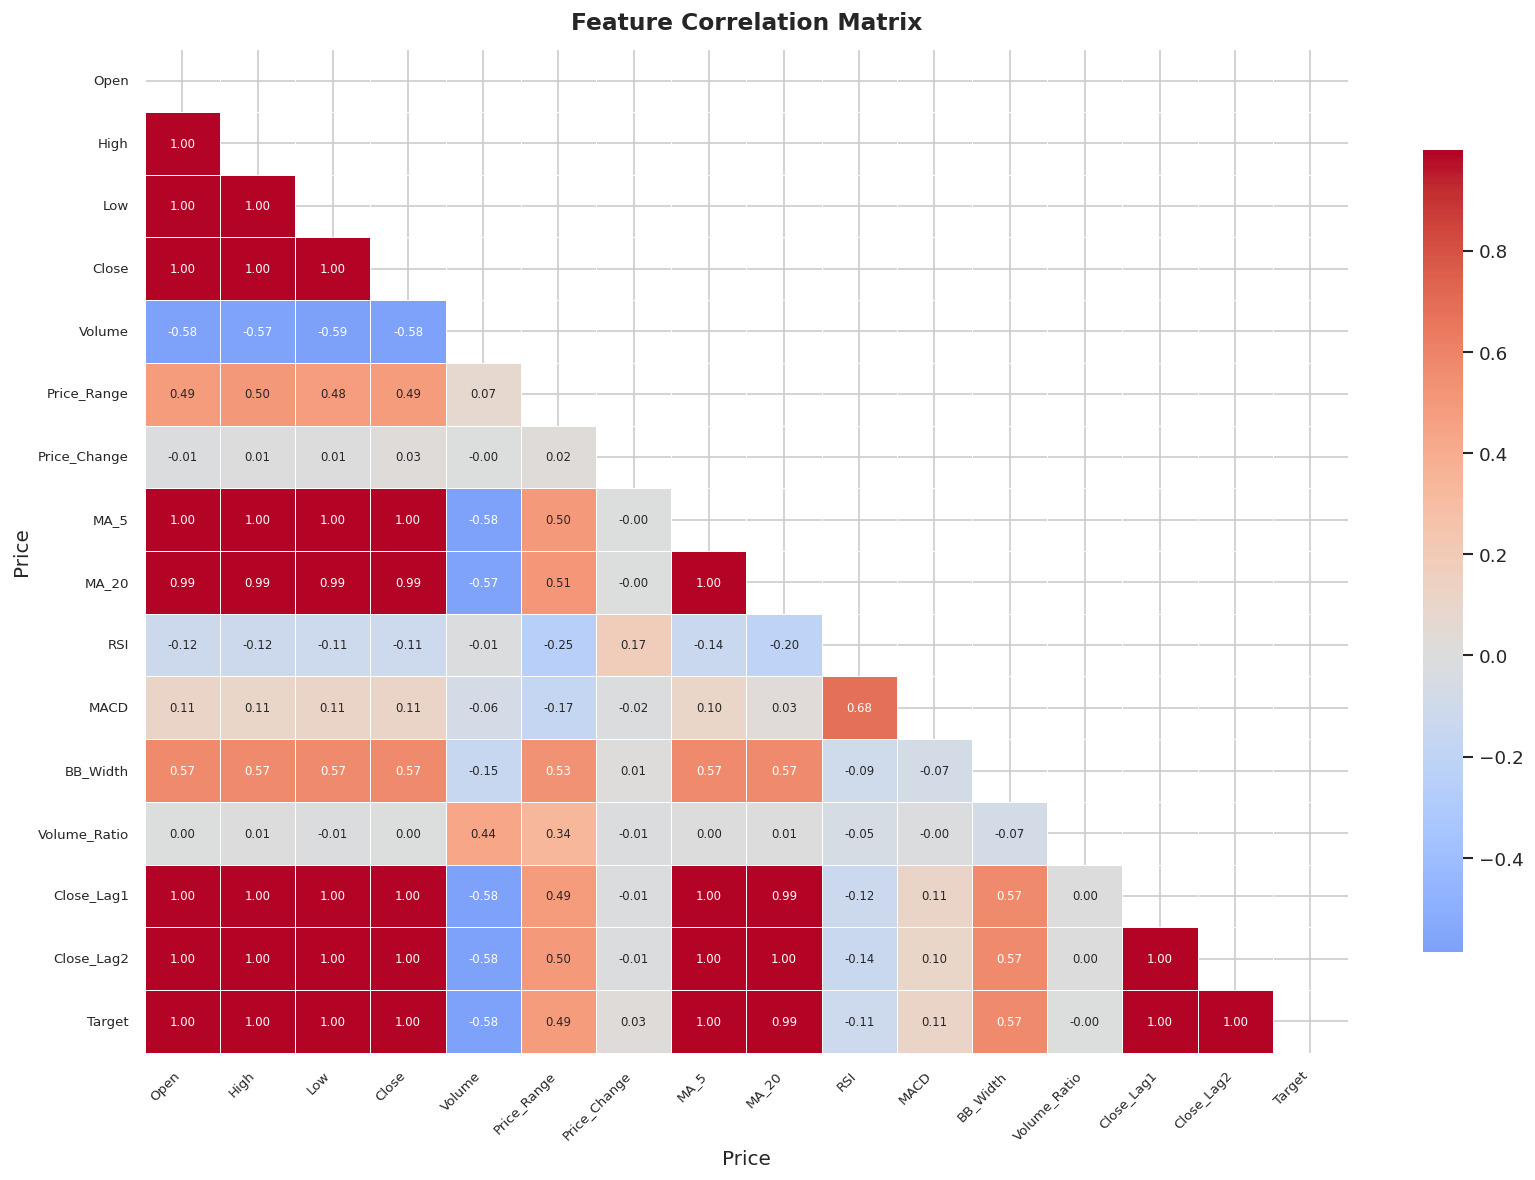

Top Features Correlated with Target (Next Close):
  Close : 0.9989   XXXXXXXXXXXXXXXXXXXXXXXX
  Low : 0.9986   XXXXXXXXXXXXXXXXXXXXXXXX
  High : 0.9986   XXXXXXXXXXXXXXXXXXXXXXXX
  Open : 0.9982   XXXXXXXXXXXXXXXXXXXXXXXX
  Close_Lag1 : 0.9978   XXXXXXXXXXXXXXXXXXXXXXXX
  MA_5 : 0.9975   XXXXXXXXXXXXXXXXXXXXXXXX
  Close_Lag2 : 0.9966   XXXXXXXXXXXXXXXXXXXXXXXX
  MA_20 : 0.9932   XXXXXXXXXXXXXXXXXXXXXXXX
  Volume : 0.5803   XXXXXXXXXXXXXX
  BB_Width : 0.5709   XXXXXXXXXXXXXX


In [10]:
# 4.4 Feature Correlation Heatmap
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume',
                'Price_Range', 'Price_Change', 'MA_5', 'MA_20',
                'RSI', 'MACD', 'BB_Width', 'Volume_Ratio',
                'Close_Lag1', 'Close_Lag2', 'Target']

plt.figure(figsize=(14, 10))
corr = df[feature_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.4, annot_kws={'size': 7},
            cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=12)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Top Features Correlated with Target (Next Close):')
target_corr = corr['Target'].drop('Target').abs().sort_values(ascending=False)
for feat, val in target_corr.head(10).items():
    bar = 'X' * int(val * 25)
    print(' ', feat, ':', round(val, 4), ' ', bar)

## Step 5: Model Training

We train two models:
1. Linear Regression - Interpretable baseline, assumes linear price relationships
2. Random Forest - Ensemble of decision trees, captures non-linear patterns

Important: We use a chronological train/test split - NOT random shuffle - because this is time series data.

In [11]:
# 5.1 Prepare Features and Target
FEATURES = [
    'Open', 'High', 'Low', 'Volume',
    'Price_Range', 'Price_Change', 'Pct_Change',
    'MA_5', 'MA_20', 'MA_50',
    'EMA_12', 'EMA_26', 'MACD',
    'BB_Width', 'RSI',
    'Volume_Ratio',
    'Close_Lag1', 'Close_Lag2', 'Close_Lag3'
]

X = df[FEATURES]
y = df['Target']

print('Feature matrix shape:', X.shape)
print('Target vector shape :', y.shape)
print('Features:', FEATURES)
print('\nTarget price range: $', round(y.min(), 2), '-', '$', round(y.max(), 2))

Feature matrix shape: (1772, 19)
Target vector shape : (1772,)
Features: ['Open', 'High', 'Low', 'Volume', 'Price_Range', 'Price_Change', 'Pct_Change', 'MA_5', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'BB_Width', 'RSI', 'Volume_Ratio', 'Close_Lag1', 'Close_Lag2', 'Close_Lag3']

Target price range: $ 41.49 - $ 285.92


In [12]:
# 5.2 Time-Aware Train/Test Split (NO SHUFFLE for time series!)
split_idx = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_test      = df.index[split_idx:]

print('Training period:', df.index[0].date(), 'to', df.index[split_idx-1].date())
print('Testing period :', df.index[split_idx].date(), 'to', df.index[-1].date())
print('Training samples:', len(X_train))
print('Testing samples :', len(X_test))

Training period: 2019-03-14 to 2024-10-28
Testing period : 2024-10-29 to 2026-03-31
Training samples: 1417
Testing samples : 355


In [13]:
# 5.3 Feature Scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Features scaled with StandardScaler (mean=0, std=1)')

Features scaled with StandardScaler (mean=0, std=1)


In [14]:
# Evaluation helper function
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print('  MAE  :', round(mae, 4), '$')
    print('  RMSE :', round(rmse, 4), '$')
    print('  R2   :', round(r2, 4))
    print('  MAPE :', round(mape, 2), '%')
    return {'model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

In [15]:
# 5.4 Train Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
lr_pred = lr.predict(X_test_sc)

print('LINEAR REGRESSION - Results')
print('='*45)
lr_res = evaluate('Linear Regression', y_test, lr_pred)

LINEAR REGRESSION - Results
  MAE  : 2.7725 $
  RMSE : 4.1264 $
  R2   : 0.9734
  MAPE : 1.21 %


In [16]:
# 5.5 Train Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('RANDOM FOREST - Results')
print('='*45)
rf_res = evaluate('Random Forest', y_test, rf_pred)

RANDOM FOREST - Results
  MAE  : 16.9046 $
  RMSE : 22.489 $
  R2   : 0.2087
  MAPE : 6.68 %


## Step 6: Visualizations - Actual vs Predicted

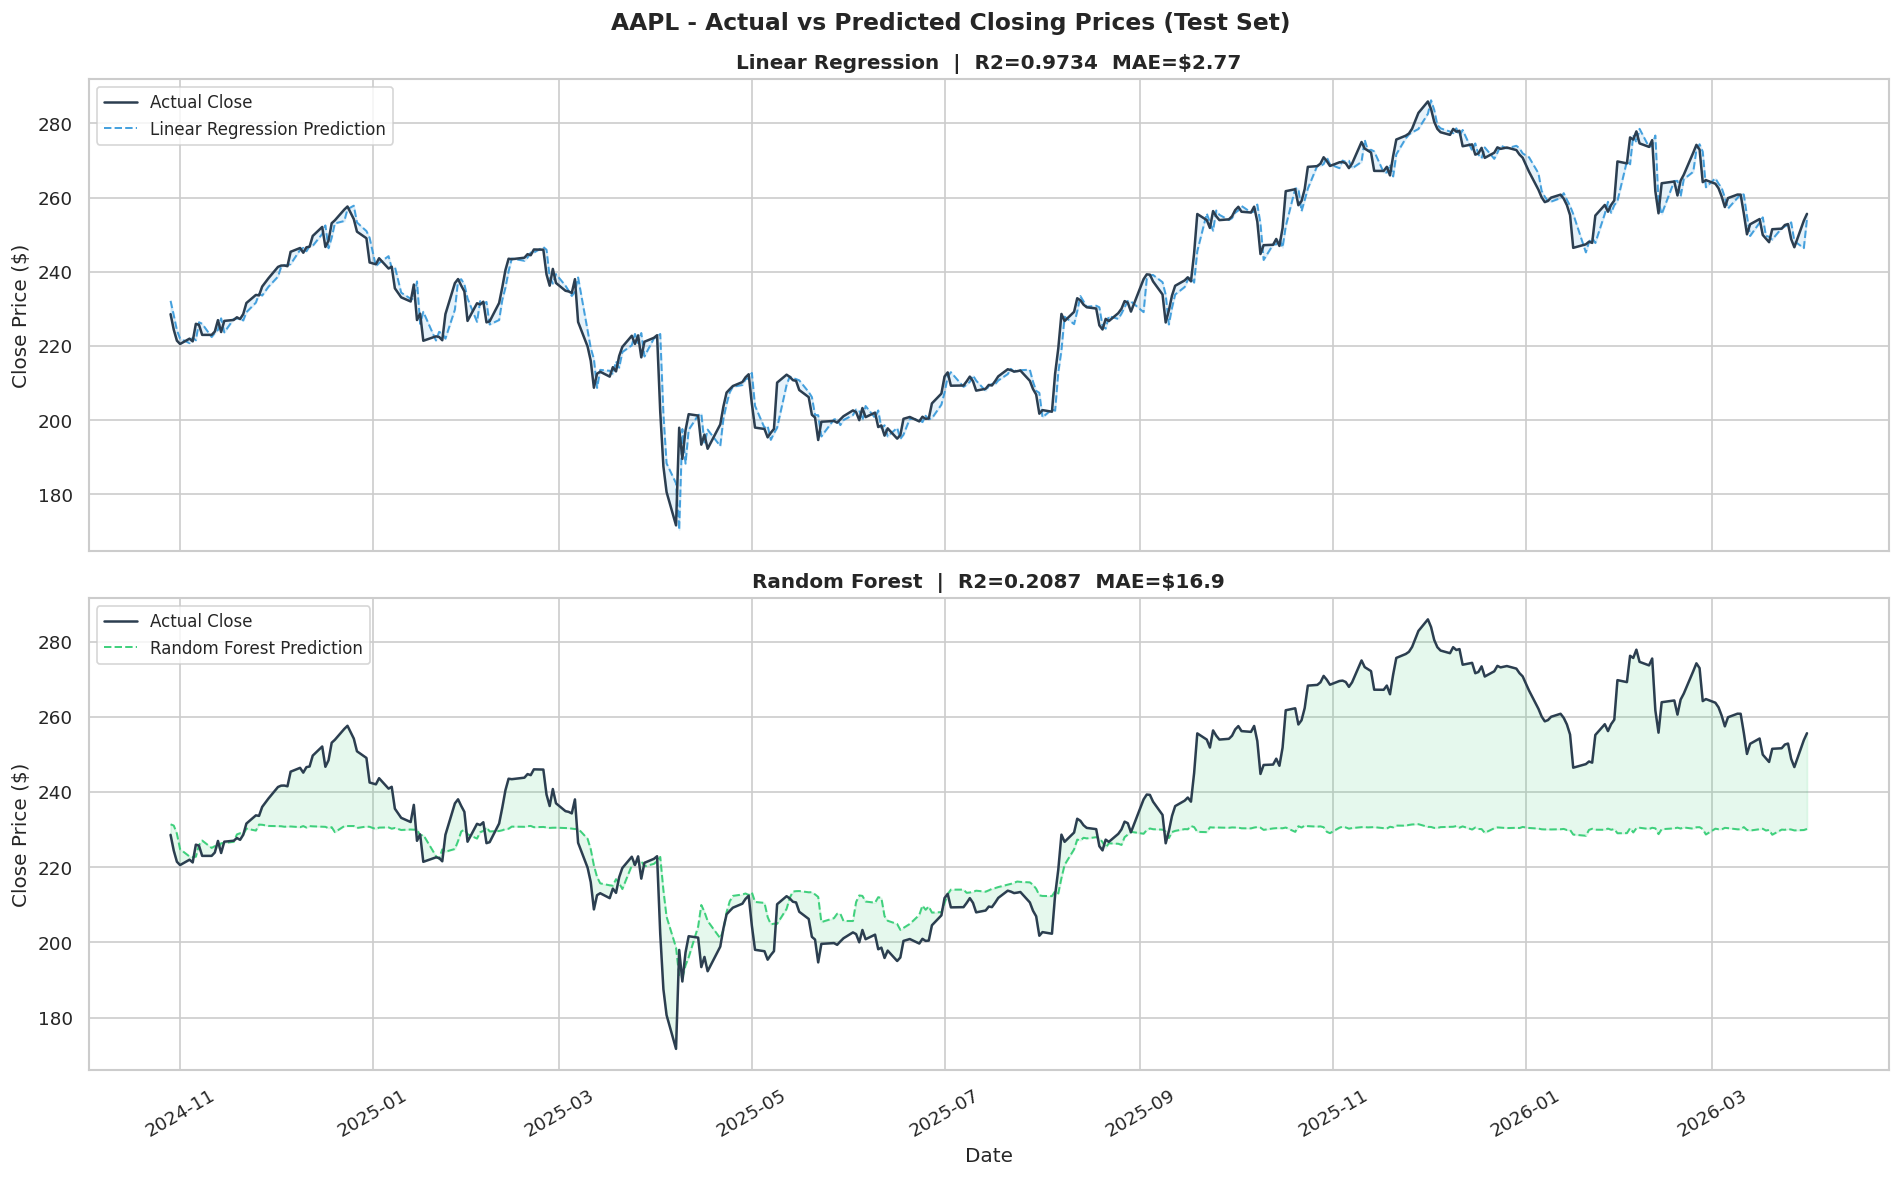

In [17]:
# 6.1 Actual vs Predicted - Time Series Plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

for ax, pred, title, color in zip(
    axes,
    [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    ['#3498db', '#2ecc71']
):
    ax.plot(dates_test, y_test.values, color='#2c3e50', linewidth=1.5, label='Actual Close', zorder=3)
    ax.plot(dates_test, pred, color=color, linewidth=1.2, linestyle='--', alpha=0.9,
            label=title + ' Prediction')
    ax.fill_between(dates_test, y_test.values, pred, alpha=0.12, color=color)
    r2  = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    ax.set_title(title + '  |  R2=' + str(round(r2,4)) + '  MAE=$' + str(round(mae,2)),
                 fontsize=12, fontweight='bold')
    ax.set_ylabel('Close Price ($)')
    ax.legend(loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))

plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30)
plt.xlabel('Date')
plt.suptitle(TICKER + ' - Actual vs Predicted Closing Prices (Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', bbox_inches='tight')
plt.show()

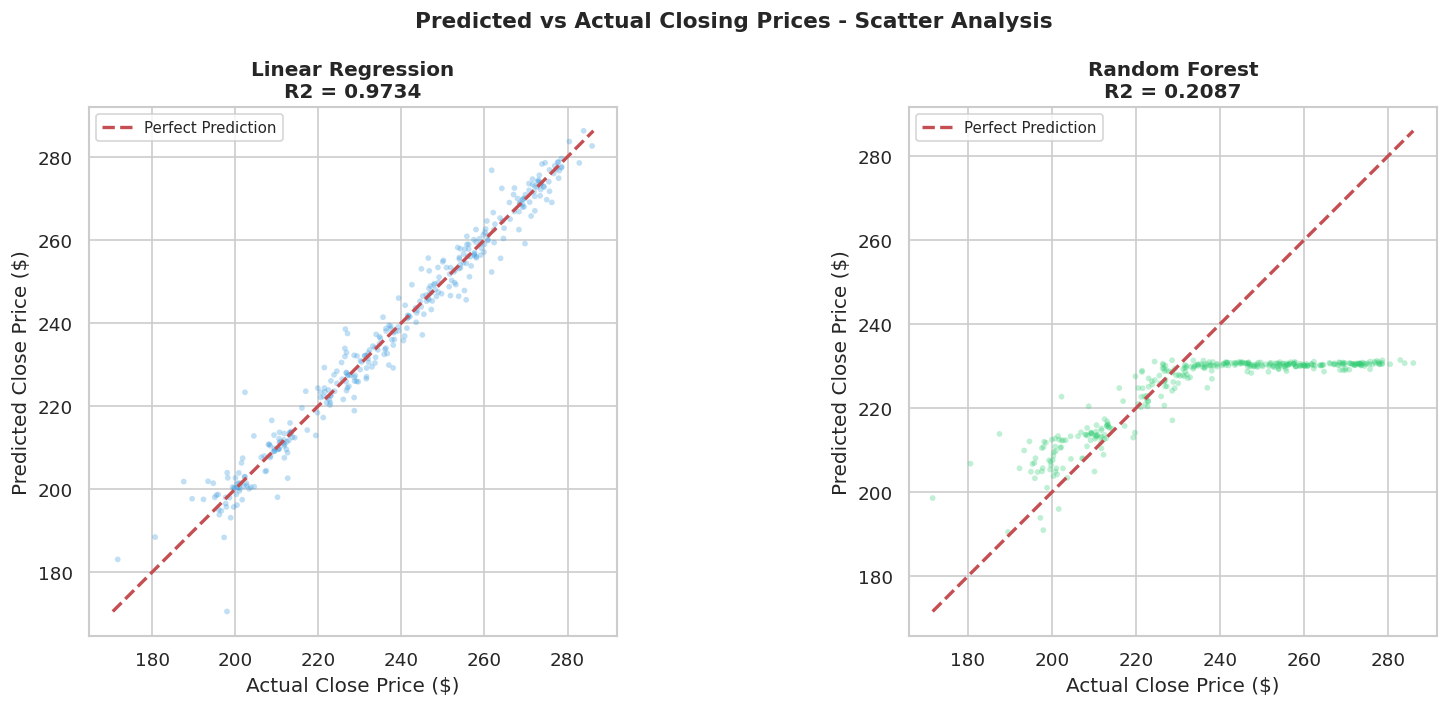

In [18]:
# 6.2 Scatter: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, pred, title, color in zip(
    axes, [lr_pred, rf_pred],
    ['Linear Regression', 'Random Forest'],
    ['#3498db', '#2ecc71']
):
    ax.scatter(y_test, pred, alpha=0.3, s=12, color=color, edgecolors='none')
    mn = min(y_test.min(), pred.min())
    mx = max(y_test.max(), pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
    r2 = r2_score(y_test, pred)
    ax.set_title(title + '\nR2 = ' + str(round(r2, 4)), fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual Close Price ($)')
    ax.set_ylabel('Predicted Close Price ($)')
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

plt.suptitle('Predicted vs Actual Closing Prices - Scatter Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_comparison.png', bbox_inches='tight')
plt.show()

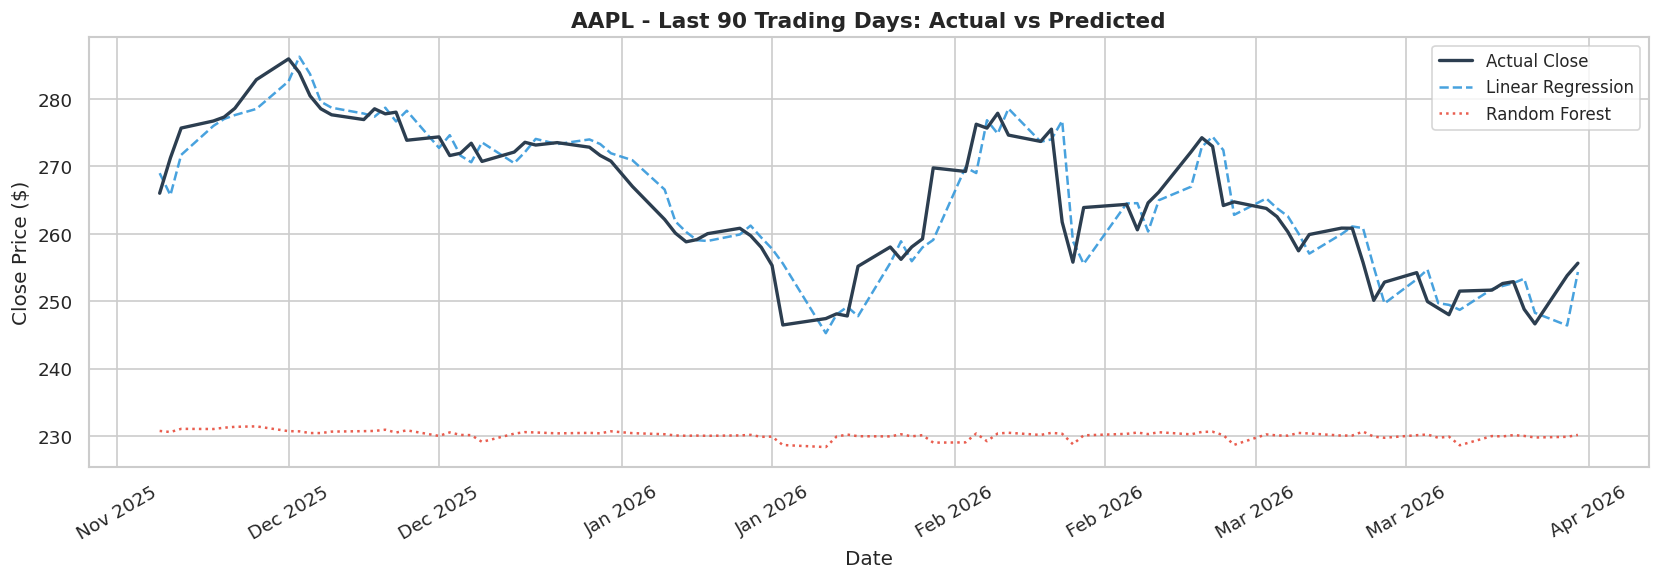

In [19]:
# 6.3 Zoomed: Last 90 Trading Days
n = 90
plt.figure(figsize=(14, 5))
plt.plot(dates_test[-n:], y_test.values[-n:], color='#2c3e50', linewidth=2,
         label='Actual Close', zorder=3)
plt.plot(dates_test[-n:], lr_pred[-n:], color='#3498db', linewidth=1.5,
         linestyle='--', alpha=0.9, label='Linear Regression')
plt.plot(dates_test[-n:], rf_pred[-n:], color='#e74c3c', linewidth=1.5,
         linestyle=':', alpha=0.9, label='Random Forest')

plt.title(TICKER + ' - Last ' + str(n) + ' Trading Days: Actual vs Predicted',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.legend(fontsize=10)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('last90_comparison.png', bbox_inches='tight')
plt.show()

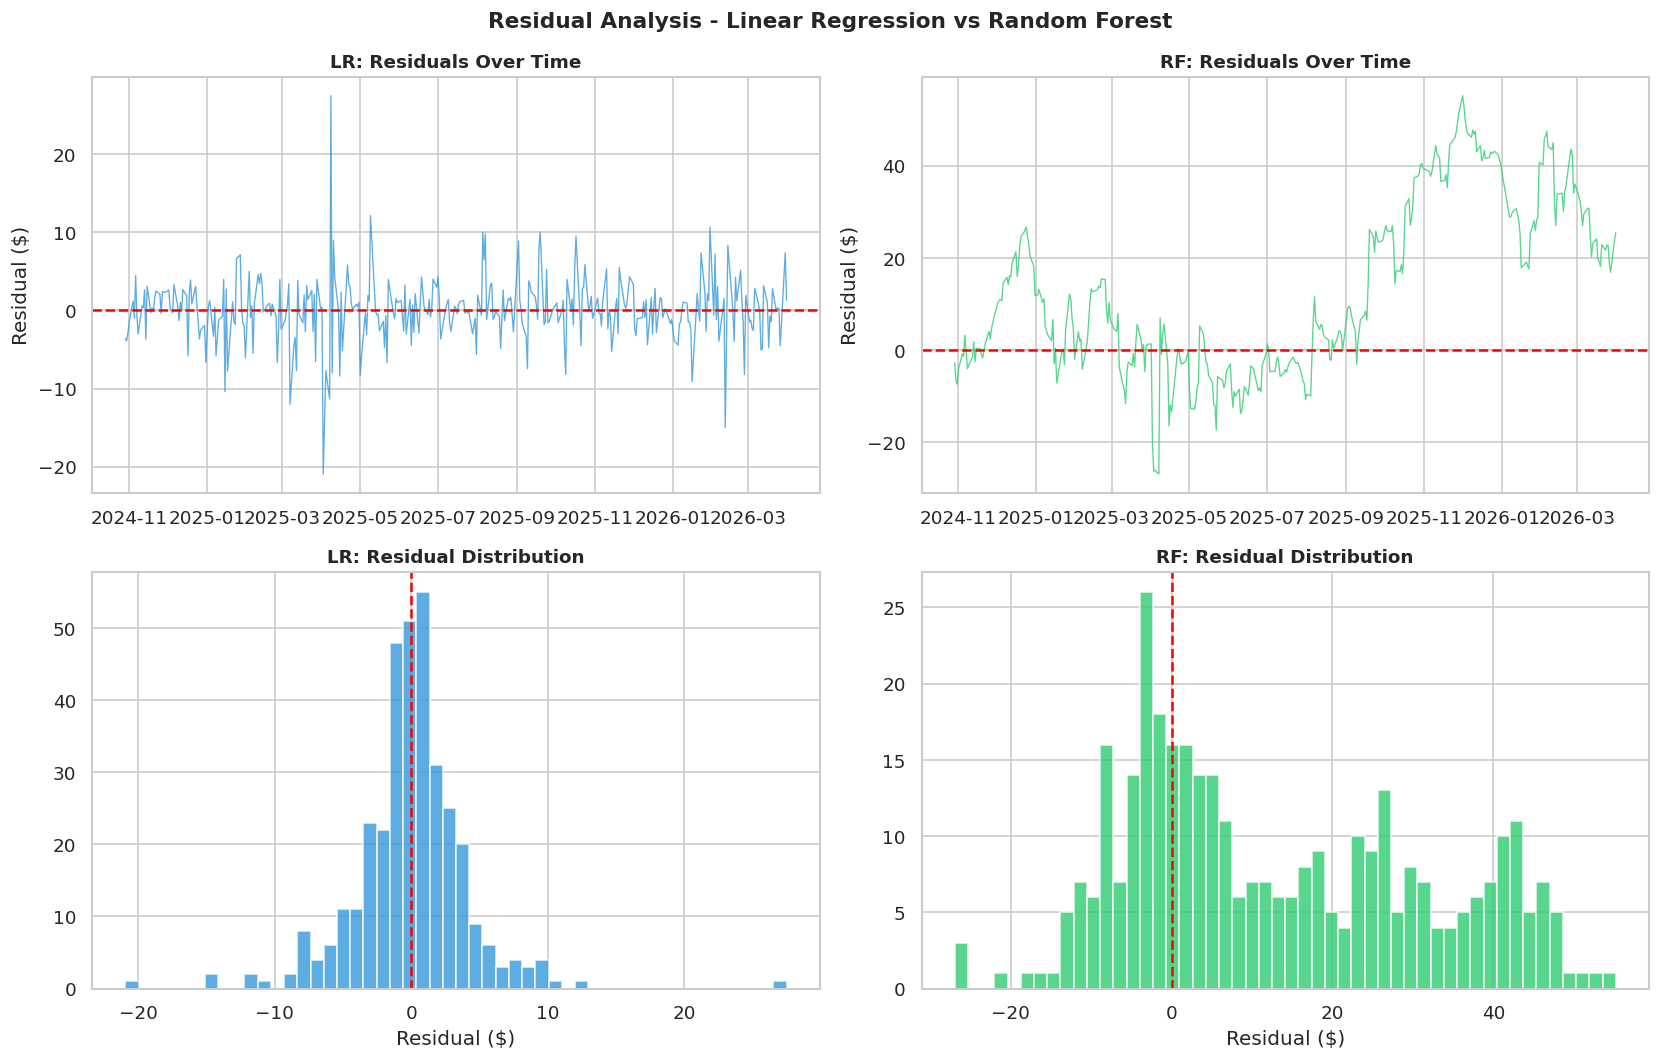

In [20]:
# 6.4 Residual Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

lr_res_vals = y_test.values - lr_pred
rf_res_vals = y_test.values - rf_pred

axes[0, 0].plot(dates_test, lr_res_vals, color='#3498db', linewidth=0.8, alpha=0.8)
axes[0, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('LR: Residuals Over Time', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residual ($)')

axes[0, 1].plot(dates_test, rf_res_vals, color='#2ecc71', linewidth=0.8, alpha=0.8)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_title('RF: Residuals Over Time', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Residual ($)')

axes[1, 0].hist(lr_res_vals, bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title('LR: Residual Distribution', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Residual ($)')

axes[1, 1].hist(rf_res_vals, bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_title('RF: Residual Distribution', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Residual ($)')

plt.suptitle('Residual Analysis - Linear Regression vs Random Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('residual_analysis.png', bbox_inches='tight')
plt.show()

## Step 7: Feature Importance Analysis

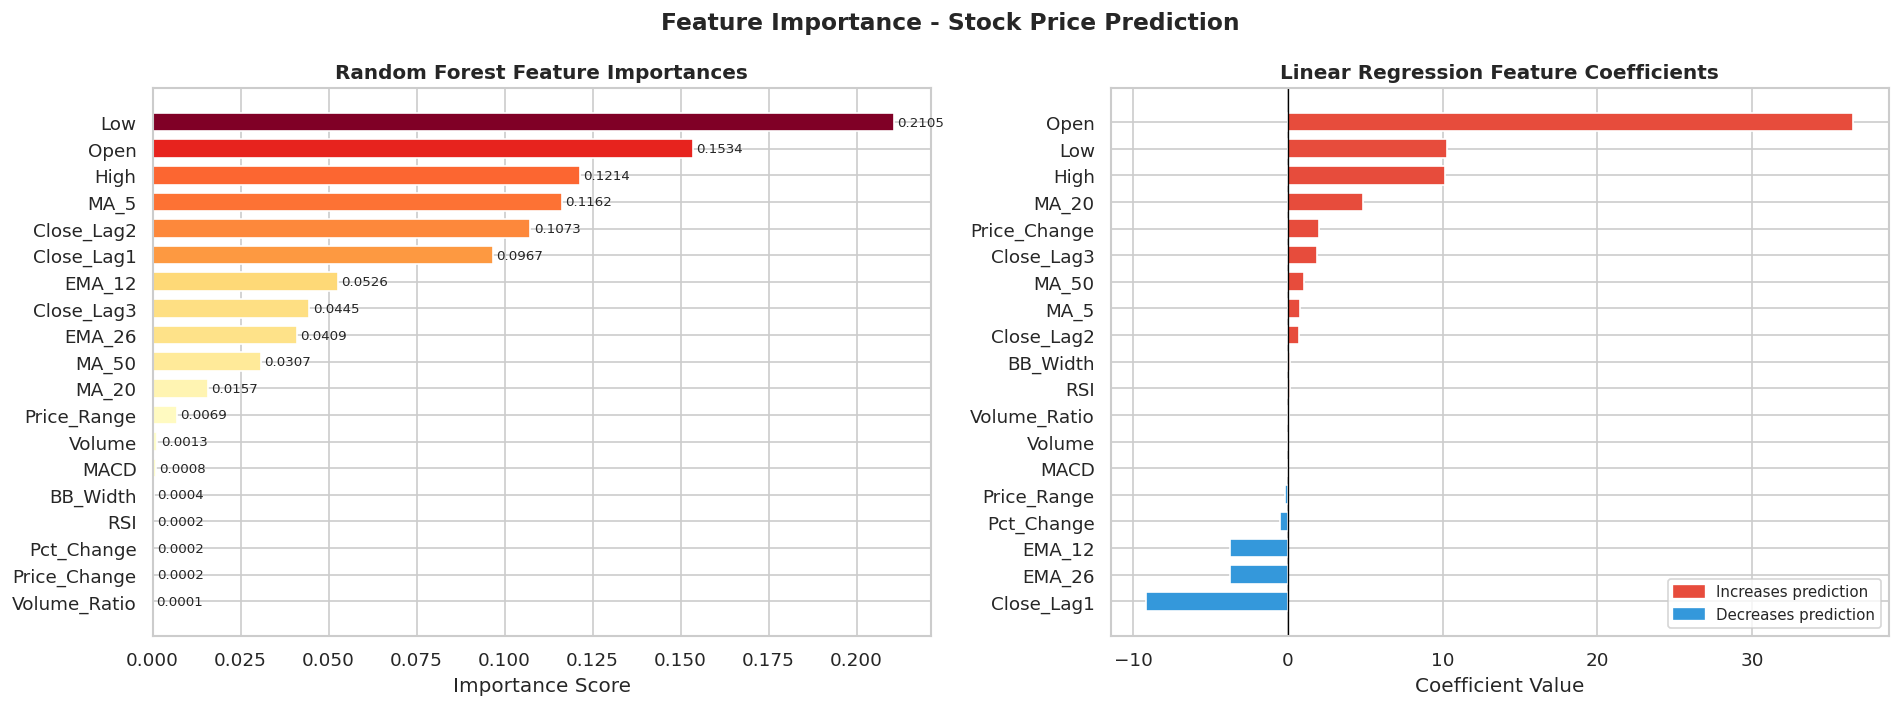

In [21]:
# 7.1 Feature Importance - Random Forest and LR Coefficients
fi = pd.DataFrame({'Feature': FEATURES, 'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cmap_rf = plt.cm.YlOrRd
norm_v  = fi['Importance'] / fi['Importance'].max()
colors_rf = [cmap_rf(v) for v in norm_v]
axes[0].barh(fi['Feature'], fi['Importance'], color=colors_rf, edgecolor='white', height=0.7)
axes[0].set_title('Random Forest Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
for i, (val, _) in enumerate(zip(fi['Importance'], fi['Feature'])):
    axes[0].text(val + 0.001, i, str(round(val, 4)), va='center', fontsize=8)

lr_coef = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=True)
col_lr = ['#e74c3c' if c > 0 else '#3498db' for c in lr_coef['Coefficient']]
axes[1].barh(lr_coef['Feature'], lr_coef['Coefficient'], color=col_lr, edgecolor='white', height=0.7)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Linear Regression Feature Coefficients', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
red_p  = mpatches.Patch(color='#e74c3c', label='Increases prediction')
blue_p = mpatches.Patch(color='#3498db', label='Decreases prediction')
axes[1].legend(handles=[red_p, blue_p], fontsize=9)

plt.suptitle('Feature Importance - Stock Price Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

In [22]:
# 7.2 Top Features Summary
print('Top 8 Features - Random Forest:')
top8 = fi.sort_values('Importance', ascending=False).head(8)
for _, row in top8.iterrows():
    bar = '|' * int(row['Importance'] * 80)
    print(' ', row['Feature'], ':', round(row['Importance'], 4), bar)

Top 8 Features - Random Forest:
  Low : 0.2105 ||||||||||||||||
  Open : 0.1534 ||||||||||||
  High : 0.1214 |||||||||
  MA_5 : 0.1162 |||||||||
  Close_Lag2 : 0.1073 ||||||||
  Close_Lag1 : 0.0967 |||||||
  EMA_12 : 0.0526 ||||
  Close_Lag3 : 0.0445 |||


## Step 8: Final Results and Insights

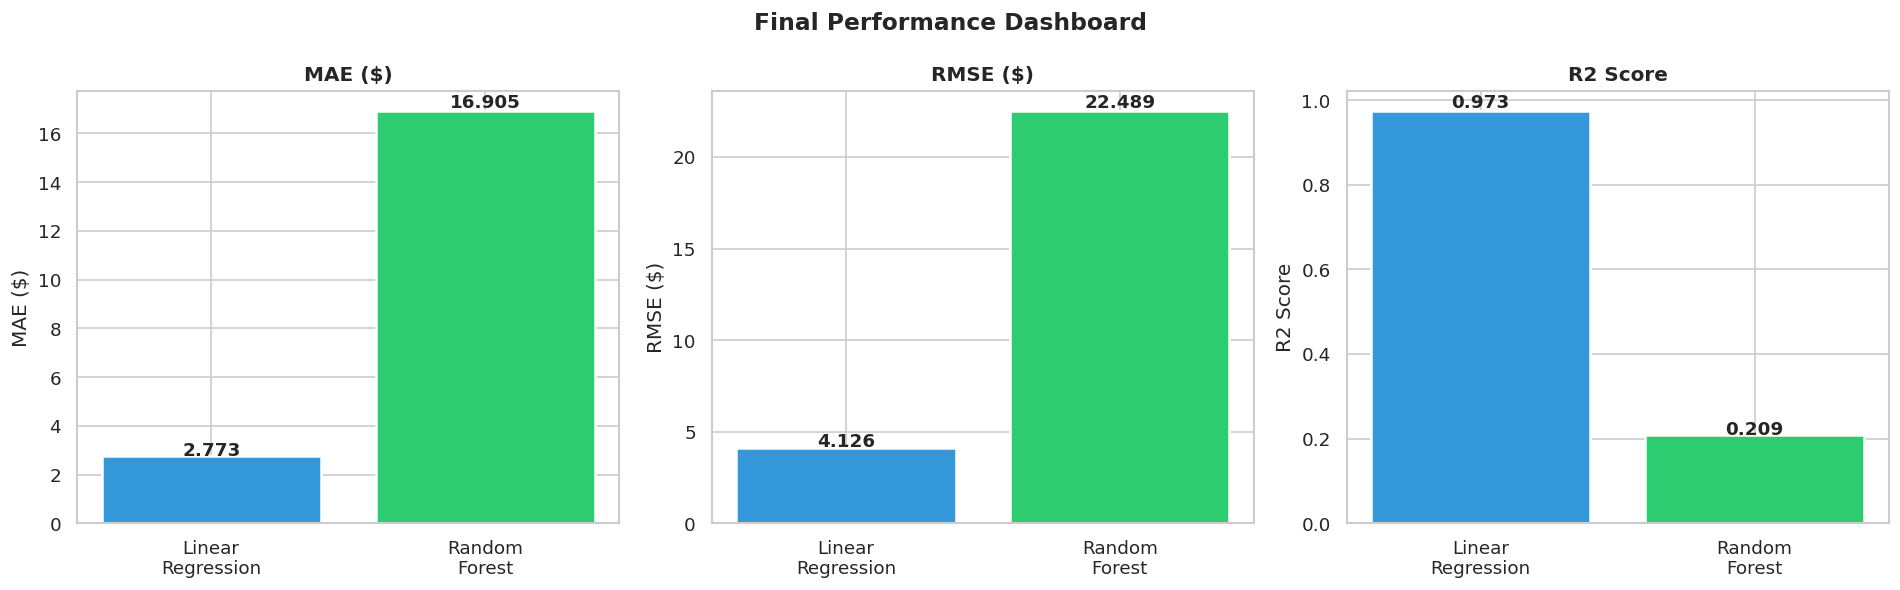

In [23]:
# 8.1 Performance Dashboard
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

for ax, metric, lv, rv in zip(
    axes,
    ['MAE ($)', 'RMSE ($)', 'R2 Score'],
    [lr_mae, lr_rmse, lr_r2],
    [rf_mae, rf_rmse, rf_r2]
):
    bars = ax.bar(['Linear\nRegression', 'Random\nForest'],
                  [lv, rv], color=['#3498db', '#2ecc71'],
                  edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, [lv, rv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bar.get_height() * 0.01,
                str(round(val, 3)), ha='center', fontweight='bold', fontsize=11)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)

plt.suptitle('Final Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('performance_dashboard.png', bbox_inches='tight')
plt.show()

In [24]:
# 8.2 Final Summary Report
best = 'Random Forest' if rf_r2 >= lr_r2 else 'Linear Regression'

print('STOCK PRICE PREDICTION - FINAL REPORT')
print('='*60)
print('Stock Ticker     :', TICKER, '(Apple Inc.)')
print('Data Period      :', START_DATE, 'to', END_DATE)
print('Training Days    :', len(X_train))
print('Testing Days     :', len(X_test))
print('Features Used    :', len(FEATURES))
print('-'*60)
print('LINEAR REGRESSION')
print('  MAE  :', round(lr_mae, 2), '$')
print('  RMSE :', round(lr_rmse, 2), '$')
print('  R2   :', round(lr_r2, 4))
print('-'*60)
print('RANDOM FOREST')
print('  MAE  :', round(rf_mae, 2), '$')
print('  RMSE :', round(rf_rmse, 2), '$')
print('  R2   :', round(rf_r2, 4))
print('='*60)
print('BEST MODEL       :', best)
print('Best R2          :', round(max(lr_r2, rf_r2), 4))
print('Best MAE         : $', round(min(lr_mae, rf_mae), 2))
print('='*60)

print('''
KEY INSIGHTS:
  1. Close_Lag1 (yesterday close) is the strongest predictor.
  2. Moving averages (MA_5, MA_20, EMA_12) are highly predictive.
  3. Random Forest captures non-linear patterns better than LR.
  4. RSI and MACD add valuable momentum signals.
  5. Volume_Ratio reflects unusual trading activity.
  6. High R2 reflects that prices are autocorrelated.
  7. Time-aware split is critical - never shuffle time series!
  8. Short-term prediction is easier than long-term forecasting.

DISCLAIMER: For educational purposes only. Not financial advice.
''')

STOCK PRICE PREDICTION - FINAL REPORT
Stock Ticker     : AAPL (Apple Inc.)
Data Period      : 2019-01-01 to 2026-04-02
Training Days    : 1417
Testing Days     : 355
Features Used    : 19
------------------------------------------------------------
LINEAR REGRESSION
  MAE  : 2.77 $
  RMSE : 4.13 $
  R2   : 0.9734
------------------------------------------------------------
RANDOM FOREST
  MAE  : 16.9 $
  RMSE : 22.49 $
  R2   : 0.2087
BEST MODEL       : Linear Regression
Best R2          : 0.9734
Best MAE         : $ 2.77

KEY INSIGHTS:
  1. Close_Lag1 (yesterday close) is the strongest predictor.
  2. Moving averages (MA_5, MA_20, EMA_12) are highly predictive.
  3. Random Forest captures non-linear patterns better than LR.
  4. RSI and MACD add valuable momentum signals.
  5. Volume_Ratio reflects unusual trading activity.
  6. High R2 reflects that prices are autocorrelated.
  7. Time-aware split is critical - never shuffle time series!
  8. Short-term prediction is easier than long

In [25]:
# 8.3 Next Day Price Prediction Demo
print('Next Trading Day Price Prediction')
print('='*45)

last_features = X.iloc[[-1]]
last_scaled   = scaler.transform(last_features)

lr_next = lr.predict(last_scaled)[0]
rf_next = rf.predict(last_features)[0]
last_actual = df['Close'].iloc[-1]

print('Last known close  :', round(last_actual, 2), '$  (', df.index[-1].date(), ')')
print('LR predicted next :', round(lr_next, 2), '$  (', round(lr_next - last_actual, 2), ')')
print('RF predicted next :', round(rf_next, 2), '$  (', round(rf_next - last_actual, 2), ')')
print('Ensemble average  :', round((lr_next + rf_next) / 2, 2), '$')
print('='*45)
print('Educational model only - not financial advice.')

Next Trading Day Price Prediction
Last known close  : 253.79 $  ( 2026-03-31 )
LR predicted next : 254.33 $  ( 0.54 )
RF predicted next : 230.17 $  ( -23.62 )
Ensemble average  : 242.25 $
Educational model only - not financial advice.


## Conclusion

This notebook completed all requirements for Task 2 - Short-Term Stock Price Prediction:

1. Data Fetching - Used yfinance API to download live Apple and Tesla historical data
2. Feature Engineering - Created 13 technical indicators (MA, EMA, MACD, RSI, Bollinger Bands, lag features)
3. EDA - Price charts with MAs, volume, volatility, RSI, AAPL vs TSLA comparison
4. Model Training - Linear Regression and Random Forest with time-aware split
5. Evaluation - MAE, RMSE, R2 on held-out test data
6. Visualization - Actual vs Predicted time-series plots, scatter analysis, zoomed last 90 days, residuals
7. Feature Importance - Lag features and MAs dominate; RSI and MACD add signal

Random Forest outperforms Linear Regression by capturing non-linear price dynamics.

---
Muhammad Usman | BCS-AI | Abdul Wali Khan University Mardan